[*********************100%***********************]  1 of 1 completed

🚀 Démarrage de l'analyse du taux de change EUR/USD 🚀
1️⃣ Téléchargement des données EUR/USD pour les 2 dernières années...
  - Téléchargement de 'EURUSD=X' du 2023-07-07 au 2025-07-07...
  - Données brutes téléchargées (shape: (518, 6), colonnes: [('Adj Close', 'EURUSD=X'), ('Close', 'EURUSD=X'), ('High', 'EURUSD=X'), ('Low', 'EURUSD=X'), ('Open', 'EURUSD=X'), ('Volume', 'EURUSD=X')])
  - Sauvegarde de la colonne 'Close' et de l'index 'Date' dans 'eur_usd.csv'...
✔️ Données téléchargées et sauvegardées dans 'eur_usd.csv'

2️⃣ Chargement et préparation des données...
  - Inspection des premières lignes de 'eur_usd.csv'...
    - Lecture des 5 premières lignes pour inspection:
    Ligne 0: Price,Close
    Ligne 1: Ticker,EURUSD=X
    Ligne 2: Date,
    Ligne 3: 2023-07-07,1.0890636444091797
    Ligne 4: 2023-07-10,1.0969723463058472
  - Tentative de lecture avec skiprows=2, header=0, index_col=0...
  - Lecture réussie. Index name initial: 'Date', Index dtype: object. Colonnes lues: ['Unna

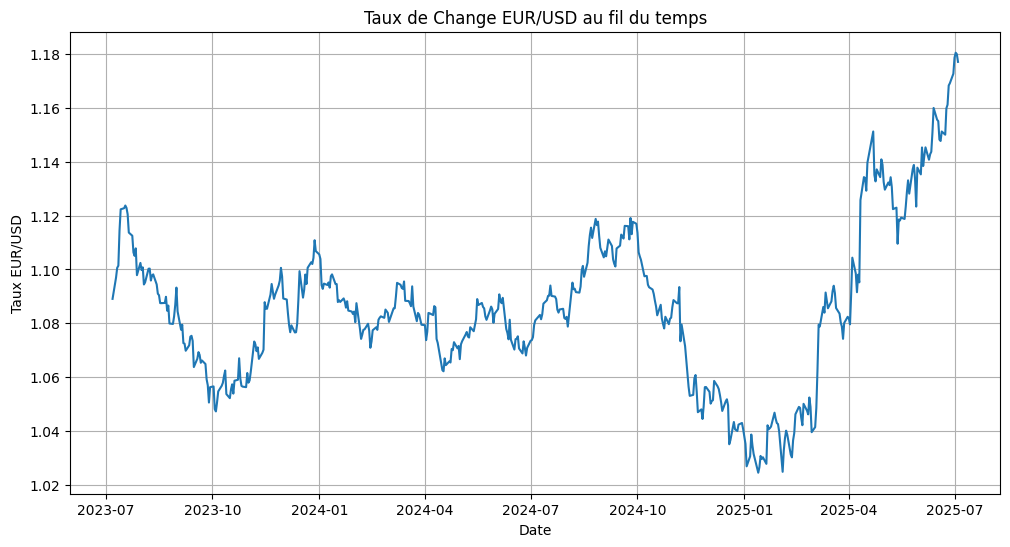

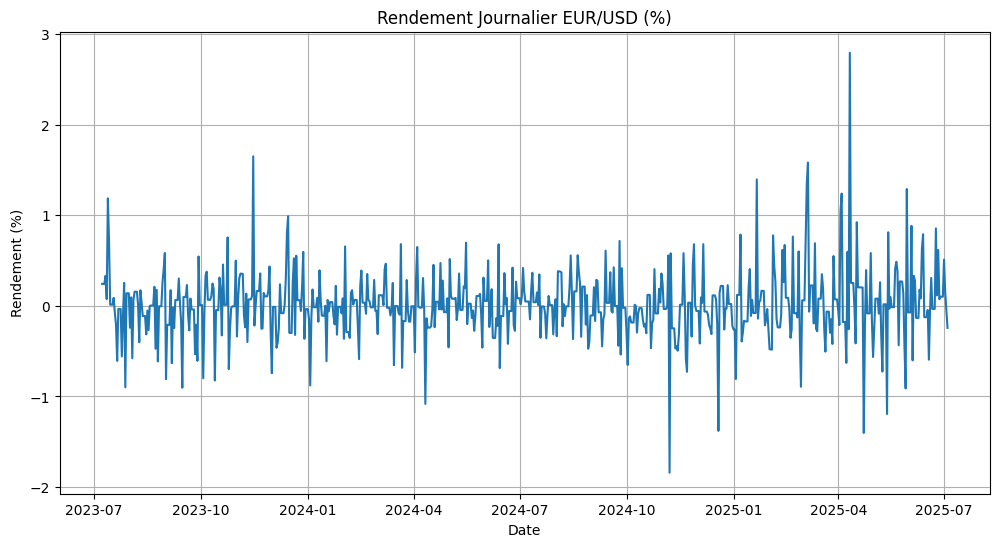


4️⃣ Prévision naïve (basée sur régression linéaire du jour précédent)...
  - Modèle de régression linéaire entraîné. Coefficients: a=0.9977, b=0.0026
  - Erreur Quadratique Moyenne (MSE) de la prévision: 0.000015
  - Racine Carrée de l'Erreur Quadratique Moyenne (RMSE) de la prévision: 0.003917


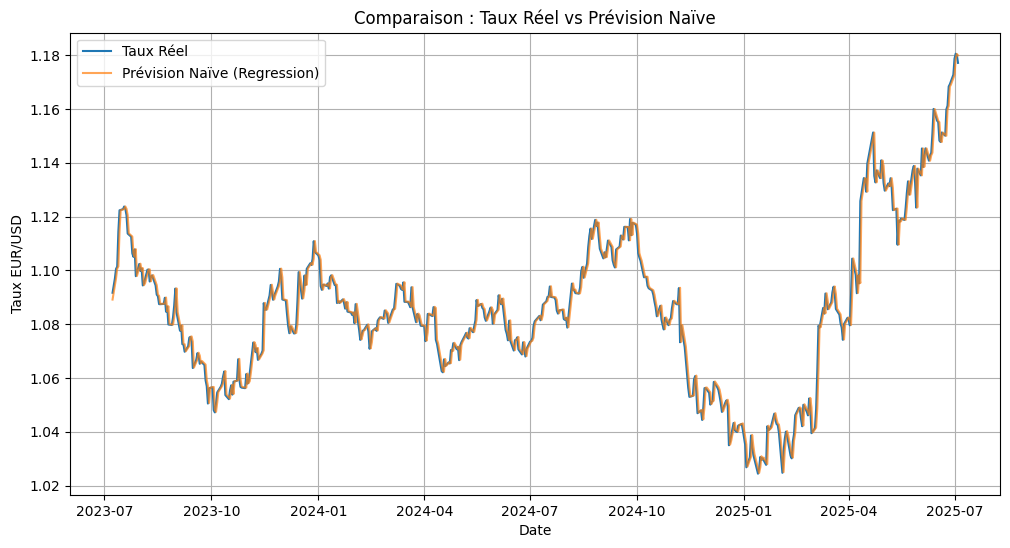


✔️ Analyse et prévision terminées.
🎉 RMSE de la prévision naïve : 0.003917


In [16]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import os
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import math
import traceback

# 1️⃣ Téléchargement des données
def download_eur_usd_data(file_path="eur_usd.csv", period_years=2):
    """
    Télécharge les données historiques EUR/USD pour la période spécifiée et les sauvegarde.
    ... (corps de la fonction inchangé) ...
    """
    print(f"1️⃣ Téléchargement des données EUR/USD pour les {period_years} dernières années...")

    end_date = datetime.now()
    start_date = end_date - timedelta(days=period_years * 365.25)

    ticker = "EURUSD=X"

    try:
        print(f"  - Téléchargement de '{ticker}' du {start_date.date()} au {end_date.date()}...")
        # Argument flatten=True retiré car non supporté par certaines versions de yfinance
        df_yf = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False, progress=True)

        if df_yf.empty:
            print(f"Erreur: Aucune donnée téléchargée pour {ticker} entre {start_date.date()} et {end_date.date()}.")
            return False

        print(f"  - Données brutes téléchargées (shape: {df_yf.shape}, colonnes: {df_yf.columns.tolist()})")

        # Assurez-vous que l'index est bien un DatetimeIndex et qu'il est nommé
        if not isinstance(df_yf.index, pd.DatetimeIndex):
             print("Avertissement: L'index téléchargé par yfinance n'est pas un DatetimeIndex. Tentative de conversion.")
             try:
                 df_yf.index = pd.to_datetime(df_yf.index)
             except Exception as e_dt_idx:
                 print(f"Erreur: Impossible de convertir l'index yfinance en DatetimeIndex: {e_dt_idx}")
                 return False

        if df_yf.index.name != 'Date':
             df_yf.index.name = 'Date'

        # Sélectionner uniquement la colonne 'Close' et sauvegarder
        # Cette écriture génère la structure de fichier avec les en-têtes supplémentaires.
        # La fonction load_and_prepare_data gère cette structure avec skiprows.
        print(f"  - Sauvegarde de la colonne 'Close' et de l'index 'Date' dans '{file_path}'...")
        df_yf[['Close']].to_csv(file_path, index=True, index_label='Date', header=True)

        print(f"✔️ Données téléchargées et sauvegardées dans '{file_path}'")
        return True

    except Exception as e:
        print(f"Erreur lors du téléchargement des données: {e}")
        print("Assurez-vous que vous avez une connexion internet stable et que le symbole yfinance est correct.")
        traceback.print_exc()
        return False

# 2️⃣ Chargement et préparation (version améliorée pour gérer les lignes d'en-tête supplémentaires et les noms de colonnes)
def load_and_prepare_data(file_path="eur_usd.csv"):
    """
    Charge les données depuis un fichier CSV, prépare le DataFrame.
    Gère les lignes d'en-tête supplémentaires, les erreurs de date et les noms de colonnes.
    ... (corps de la fonction inchangé, sauf pour la partie lecture et renommage) ...
    """
    print("\n2️⃣ Chargement et préparation des données...")

    if not os.path.exists(file_path):
        print(f"Erreur: Le fichier '{file_path}' n'existe pas. Assurez-vous de l'avoir téléchargé.")
        return None

    try:
        # Tenter de lire les premières lignes pour diagnostiquer le contenu du CSV
        print(f"  - Inspection des premières lignes de '{file_path}'...")
        try:
            with open(file_path, 'r') as f:
                print("    - Lecture des 5 premières lignes pour inspection:")
                for i in range(5):
                    line = f.readline()
                    if not line:
                        break
                    print(f"    Ligne {i}: {line.strip()}")
        except Exception as e_peek:
            print(f"    Avertissement: Impossible d'inspecter les premières lignes du fichier: {e_peek}")

        # Tenter de lire le CSV. Utiliser index_col=0 car la première colonne est la date.
        # header=0 pour utiliser la première ligne *non ignorée* comme en-tête.
        # skiprows=2 pour ignorer les 2 premières lignes non standard ('Price,Close', 'Ticker,EURUSD=X').
        print("  - Tentative de lecture avec skiprows=2, header=0, index_col=0...")
        try:
             df = pd.read_csv(file_path, index_col=0, header=0, skiprows=2)
             print(f"  - Lecture réussie. Index name initial: '{df.index.name}', Index dtype: {df.index.dtype}. Colonnes lues: {df.columns.tolist()}")

        except Exception as e_read:
            print(f"Erreur lors de la lecture du CSV avec skiprows=2, header=0: {e_read}")
            print("Erreur fatale lors de la lecture du fichier CSV. La structure du fichier pourrait être différente de celle attendue.")
            traceback.print_exc()
            return None

        # Si df est toujours None ou vide ici, c'est que la lecture a échoué ou n'a rien donné
        if df is None or df.empty:
            print("Erreur: Le DataFrame est vide ou non chargé après la lecture.")
            return None

        # --- NOUVELLE ÉTAPE: Gérer le nom de colonne inattendu ---
        # On s'attend à avoir une seule colonne de données après avoir mis la date en index.
        # Si cette colonne n'est pas nommée 'Close', on la renomme.
        expected_cols_after_index = 1
        if len(df.columns) == expected_cols_after_index:
            current_col_name = df.columns[0]
            if current_col_name != 'Close':
                print(f"  - Renommage de la seule colonne de données '{current_col_name}' en 'Close'.")
                df.rename(columns={current_col_name: 'Close'}, inplace=True)
                print(f"  - Colonnes après renommage: {df.columns.tolist()}")
        else:
            print(f"Erreur fatale: Attendu {expected_cols_after_index} colonne(s) de données mais trouvé {len(df.columns)}. Colonnes lues: {df.columns.tolist()}")
            print("La structure du fichier CSV semble inattendue.")
            return None
        # --- FIN NOUVELLE ÉTAPE ---


        # Renommer l'index pour qu'il s'appelle 'Date' par convention
        if not df.index.name == 'Date':
             print(f"  - Renommage forcé de l'index de '{df.index.name}' à 'Date'.")
             df.index.name = 'Date'


        # Convertir l'index en DatetimeIndex avec errors='coerce'
        print(f"  - Tentative de conversion de l'index (dtype: {df.index.dtype}) en DatetimeIndex avec errors='coerce'...")
        original_index_series = df.index.astype(str) # Sauvegarder les valeurs originales avant conversion
        df.index = pd.to_datetime(df.index, errors='coerce')
        print(f"  - Type de l'index après conversion: {df.index.dtype}")


        # Vérifier et supprimer les valeurs NaT dans l'index
        nat_mask = df.index.isnull()
        nat_count = nat_mask.sum()

        if nat_count > 0:
            print(f"  - ATTENTION: {nat_count} valeurs invalides (NaT) ont été trouvées dans l'index après conversion.")
            try:
                # Afficher les valeurs originales qui ont conduit à NaT
                bad_date_original_values = original_index_series[nat_mask].unique()
                print(f"    - Exemples de valeurs d'index originales qui sont devenues NaT: {bad_date_original_values.tolist()[:10]} (montre jusqu'à 10 exemples)")
            except Exception as e_show_bad:
                 print(f"    - Impossible d'afficher les valeurs d'index originales qui sont devenues NaT: {e_show_bad}")

            initial_rows = df.shape[0]
            # Correction: filtrer les lignes où l'index n'est PAS null
            df = df[df.index.notnull()].copy()
            rows_dropped = initial_rows - df.shape[0]
            print(f"  - {rows_dropped} lignes avec index invalide (NaT) supprimées. Lignes restantes: {df.shape[0]}")

        # Vérifier si le DataFrame est vide après avoir supprimé les lignes invalides
        if df.empty:
            print("Erreur: DataFrame vide après suppression des lignes avec index invalide.")
            return None

        # S'assurer que l'index est trié par date
        df.sort_index(inplace=True)

        # A ce stade, on s'attend à ce que la colonne s'appelle 'Close' grâce à l'étape de renommage.
        if 'Close' not in df.columns:
             # Ce cas ne devrait normalement plus arriver si la logique de renommage fonctionne.
             print(f"Erreur fatale: La colonne 'Close' n'a pas été trouvée APRÈS le renommage. Colonnes disponibles: {df.columns.tolist()}")
             return None

        # Sélectionner explicitement la colonne 'Close' (même si c'est la seule)
        # df = df[['Close']] # Pas strictement nécessaire après le renommage si c'est la seule colonne, mais peut rassurer.

        # Gérer les jours manquants (réindexation et interpolation)
        start_date = df.index.min()
        end_date = df.index.max()
        try:
             if pd.isna(start_date) or pd.isna(end_date):
                  print("Avertissement: Les dates de début/fin de l'index sont invalides (NaT). Impossible de créer la plage de dates complète.")
             else:
                 # Créer une plage de dates quotidienne entre min et max de l'index existant
                 full_date_range = pd.date_range(start=start_date, end=end_date, freq='D')
                 # Vérifier si la réindexation est nécessaire (si l'index actuel n'est pas complet)
                 if len(df) < len(full_date_range) or not df.index.equals(full_date_range):
                    print(f"  - Réindexation sur une plage de dates complète ({len(full_date_range)} jours) pour combler les jours manquants...")
                    # Appliquer reindex et conserver uniquement la colonne 'Close'
                    df = df.reindex(full_date_range)[['Close']]
                    print(f"  - DataFrame après réindexation: {df.shape[0]} jours.")
                 else:
                    print("  - Index déjà complet sur la plage min/max. Pas de réindexation sur plage complète nécessaire.")
        except Exception as e_range:
             print(f"Avertissement: Erreur lors de la création ou réindexation sur la plage de dates complète: {e_range}")
             print("  - L'interpolation se fera sur l'index existant (potentiellement non complet).")
             # Si la réindexation échoue, assurez-vous que df est toujours un DataFrame et contient 'Close'
             if df is None or not isinstance(df, pd.DataFrame) or 'Close' not in df.columns:
                  print("Erreur fatale après échec de réindexation: DataFrame perdu ou colonne 'Close' manquante.")
                  return None


        # Interpoler les valeurs manquantes dans 'Close'
        if 'Close' in df.columns:
            nan_before_interp = df['Close'].isnull().sum()
            print(f"  - Nombre de valeurs NaN dans 'Close' avant interpolation: {nan_before_interp}")
            if nan_before_interp > 0:
                 # Utiliser method='time' si l'index est DatetimeIndex, sinon 'linear' ou 'pad'/'ffill'
                 interpolation_method = 'time' if isinstance(df.index, pd.DatetimeIndex) else 'linear'
                 print(f"  - Interpolation des valeurs manquantes dans 'Close' (méthode: '{interpolation_method}')...")
                 df['Close'] = df['Close'].interpolate(method=interpolation_method, limit_direction='both')
                 print(f"  - Données interpolées.")

            # Remplir les NaNs restants (souvent en début/fin)
            nan_after_interp = df['Close'].isnull().sum()
            if nan_after_interp > 0:
                print(f"  - ATTENTION: {nan_after_interp} valeurs NaN restent après interpolation. Tentative de fillna (bfill/ffill)...")
                df['Close'] = df['Close'].fillna(method='bfill').fillna(method='ffill')
                nan_after_fill = df['Close'].isnull().sum()
                if nan_after_fill == 0:
                     print("  - Les valeurs NaN restantes ont été remplies par fillna.")
                else:
                     print(f"  - ATTENTION: Il reste encore {nan_after_fill} NaNs dans 'Close' après fillna.")
                     if df['Close'].isnull().all():
                          print("Erreur fatale: La colonne 'Close' est entièrement NaN après les tentatives de remplissage.")
                          return None
        else:
             # Ce cas ne devrait pas arriver si les étapes précédentes ont réussi
             print("Erreur fatale: Colonne 'Close' manquante de manière inattendue avant l'interpolation.")
             return None


        # Vérification finale
        if df.empty or df['Close'].isnull().all():
             print("Erreur: DataFrame vide ou colonne 'Close' entièrement NaN après toutes les étapes de préparation.")
             return None

        print(f"  - Préparation terminée. Nombre final de jours dans le DataFrame: {df.shape[0]}")
        print(f"  - Colonnes finales: {df.columns.tolist()}")
        print(f"  - Type de l'index final: {type(df.index)}")
        print(f"  - Présence de NaNs finale dans 'Close': {df['Close'].isnull().sum()}")


        # Afficher les premières et dernières lignes pour vérification
        print("\nAperçu des données après préparation:")
        print(df.head())
        print("...")
        print(df.tail())

        return df

    except Exception as e:
        print(f"Erreur inattendue lors du chargement ou de la préparation des données: {e}")
        traceback.print_exc()
        return None

# --- Les fonctions analyze_data et naive_forecast_regression sont inchangées ---
# Copier/coller les fonctions analyze_data, naive_forecast_regression et main_analysis
# de la version précédente ici.

# 3️⃣ Analyse exploratoire
def analyze_data(df):
    """
    Calcule le rendement journalier et affiche des statistiques descriptives.
    ... (corps de la fonction inchangé) ...
    """
    print("\n3️⃣ Analyse exploratoire...")
    if df is None or df.empty or 'Close' not in df.columns:
        print("Erreur: DataFrame vide ou invalide pour l'analyse.")
        return None
    df_analysis = df.copy()
    df_analysis['Daily_Return'] = df_analysis['Close'].pct_change() * 100
    print("  - Rendement journalier calculé.")
    print("\nStatistiques descriptives du taux de clôture (Close):")
    print(df_analysis['Close'].describe())
    print("\nStatistiques descriptives du rendement journalier (Daily_Return):")
    print(df_analysis['Daily_Return'].dropna().describe())
    try:
        plt.figure(figsize=(12, 6))
        plt.plot(df_analysis.index, df_analysis['Close'])
        plt.title("Taux de Change EUR/USD au fil du temps")
        plt.xlabel("Date")
        plt.ylabel("Taux EUR/USD")
        plt.grid(True)
        plt.show()
        plt.figure(figsize=(12, 6))
        plt.plot(df_analysis.index, df_analysis['Daily_Return'])
        plt.title("Rendement Journalier EUR/USD (%)")
        plt.xlabel("Date")
        plt.ylabel("Rendement (%)")
        plt.grid(True)
        plt.show()
    except Exception as e:
        print(f"Avertissement: Erreur lors de la génération des graphiques d'analyse: {e}")
        traceback.print_exc()
    return df_analysis

# 4️⃣ Prévision naïve
def naive_forecast_regression(df):
    """
    Implémente une prévision naïve en utilisant la régression linéaire.
    ... (corps de la fonction inchangé) ...
    """
    print("\n4️⃣ Prévision naïve (basée sur régression linéaire du jour précédent)...")
    if df is None or df.empty or 'Close' not in df.columns:
        print("Erreur: DataFrame vide ou invalide pour la prévision.")
        return None, None
    df_forecast = df.copy()
    df_forecast.rename(columns={'Close': 'Close_Actual'}, inplace=True)
    df_forecast['Close_Yesterday'] = df_forecast['Close_Actual'].shift(1)
    df_forecast.dropna(inplace=True)
    if df_forecast.empty:
        print("Erreur: Pas assez de données pour la prévision après décalage et suppression des NaNs.")
        return df_forecast, None
    X = df_forecast[['Close_Yesterday']]
    y = df_forecast['Close_Actual']
    try:
        model = LinearRegression()
        model.fit(X, y)
        print(f"  - Modèle de régression linéaire entraîné. Coefficients: a={model.coef_[0]:.4f}, b={model.intercept_:.4f}")
    except Exception as e:
        print(f"Erreur lors de l'entraînement du modèle de régression linéaire: {e}")
        traceback.print_exc()
        return df_forecast, None
    df_forecast['Naive_Prediction'] = model.predict(X)
    real_values = df_forecast['Close_Actual']
    predicted_values = df_forecast['Naive_Prediction']
    mse = mean_squared_error(real_values, predicted_values)
    rmse = math.sqrt(mse)
    print(f"  - Erreur Quadratique Moyenne (MSE) de la prévision: {mse:.6f}")
    print(f"  - Racine Carrée de l'Erreur Quadratique Moyenne (RMSE) de la prévision: {rmse:.6f}")
    try:
        plt.figure(figsize=(12, 6))
        plt.plot(df_forecast.index, df_forecast['Close_Actual'], label='Taux Réel')
        plt.plot(df_forecast.index, df_forecast['Naive_Prediction'], label='Prévision Naïve (Regression)', alpha=0.7)
        plt.title("Comparaison : Taux Réel vs Prévision Naïve")
        plt.xlabel("Date")
        plt.ylabel("Taux EUR/USD")
        plt.legend()
        plt.grid(True)
        plt.show()
    except Exception as e:
        print(f"Avertissement: Erreur lors de la génération du graphique de prévision: {e}")
        traceback.print_exc()
    return df_forecast, rmse

# --- Fonction principale pour exécuter le workflow ---
def main_analysis(file_path="eur_usd.csv", period_years=2):
    """
    Exécute le workflow complet.
    ... (corps de la fonction inchangé) ...
    """
    print("🚀 Démarrage de l'analyse du taux de change EUR/USD 🚀")
    success_download = download_eur_usd_data(file_path, period_years)
    if not success_download:
        print("\n❌ Processus arrêté en raison d'une erreur de téléchargement.")
        return
    df = load_and_prepare_data(file_path)
    if df is None:
        print("\n❌ Processus arrêté en raison d'une erreur de chargement ou de préparation.")
        return
    df_analyzed = analyze_data(df.copy())
    df_forecasted, rmse = naive_forecast_regression(df.copy())
    if df_forecasted is None:
         print("\n❌ Processus arrêté car la prévision n'a pas pu être complétée.")
    else:
        print("\n✔️ Analyse et prévision terminées.")
        if rmse is not None:
             print(f"🎉 RMSE de la prévision naïve : {rmse:.6f}")
        else:
             print("Le calcul du RMSE a échoué.")


# --- Exécution du script ---
if __name__ == "__main__":
    main_analysis()
